In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

## **Step 3: Data Collection & Processing**

a) & b)

In [2]:
# Define stock tickers
fin_symbols = ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC']
nonfin_symbols = ['KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS', 'WELL']

# Download Adjusted Close Prices for Sep-Oct 2008
start_date = '2008-09-01'
end_date = '2008-10-31'

fin_data = yf.download(fin_symbols, start=start_date, end=end_date, auto_adjust=True)
nonfin_data = yf.download(nonfin_symbols, start=start_date, end=end_date, auto_adjust=True)

# Combine datasets and calculate returns
all_data = pd.concat([fin_data, nonfin_data], axis=1)
returns = all_data.pct_change().dropna()

print('Sample daily returns:')
returns.head()

[*********************100%***********************]  14 of 14 completed
[*********************100%***********************]  15 of 15 completed


Sample daily returns:


Price          Close                                                    \
Ticker           AXP       BAC         C       COF        GS       JPM   
Date                                                                     
2008-09-03  0.006891  0.030322  0.026164  0.016474  0.013851  0.018466   
2008-09-04 -0.052799 -0.071602 -0.066802 -0.051030 -0.040033 -0.045329   
2008-09-05  0.016774  0.053268  0.042077  0.031849  0.014543  0.044580   
2008-09-08  0.028426  0.077568  0.065548  0.089913  0.039758  0.049243   
2008-09-09 -0.056269 -0.063634 -0.070866 -0.066284 -0.047487 -0.050060   

Price                                               ...    Volume            \
Ticker           KEY        MS       PNC       PRU  ...      EQIX         F   
Date                                                ...                       
2008-09-03  0.008731  0.021066  0.009259  0.026602  ...  0.293063  0.568362   
2008-09-04 -0.062156 -0.043396 -0.018484 -0.031950  ...  0.024551  0.045595   
2008-09-05  0.088087  0.025285  0.021168  0.023129  ... -0.056579 -0.314330   
2008-09-08  0.059368  0.046179  0.033517  0.078486  ...  0.330080  0.203109   
2008-09-09 -0.042941 -0.066327 -0.051185 -0.060292  ... -0.069667 -0.285101   

Price                                                                   \
Ticker            GE        KR      NFLX       PFE      REGN      WELL   
Date                                                                     
2008-09-03 -0.368950 -0.139729 -0.394784  0.014067  1.798652  2.698229   
2008-09-04  0.624978 -0.328306  1.439182  0.533437 -0.678469  0.269298   
2008-09-05 -0.169307  0.766876 -0.172149 -0.117424  0.667156  1.791511   
2008-09-08  0.687832  0.159493  0.020058  0.193289 -0.453280 -0.652933   
2008-09-09 -0.142174  0.084917 -0.163965  0.117660  0.022068 -0.237979   

Price                           
Ticker           WMT       XOM  
Date                            
2008-09-03 -0.312697 -0.147481  
2008-09-04  0.745063  0.191966  
2008-09-05 -0.173444 -0.134516  
2008-09-08  0.251510  0.120341  
2008-09-09 -0.111896  0.232208  

[5 rows x 145 columns]

c)

In [3]:
import pandas as pd

# Combine both datasets into a single DataFrame
combined_data = pd.concat([fin_data, nonfin_data], axis=1)

# Save combined prices to CSV
combined_data.to_csv('combined_stocks_prices.csv')
print("Combined stock prices saved to 'combined_stocks_prices.csv'")

# Calculate daily returns (percentage change)
daily_returns = combined_data.pct_change().dropna()

# Save daily returns to CSV
daily_returns.to_csv('daily_returns.csv')
print("Daily returns saved to 'daily_returns.csv'")

# Print summary
print("\nData Summary:")
print(f"Combined data shape: {combined_data.shape}")
print(f"Date range: {combined_data.index.min().date()} to {combined_data.index.max().date()}")
print(f"Number of trading days: {len(combined_data)}")
print(f"Number of stocks: {len(combined_data.columns)}")

# Verify data
print("\nFirst 3 rows of returns data:")
print(daily_returns.head(3))

Combined stock prices saved to 'combined_stocks_prices.csv'
Daily returns saved to 'daily_returns.csv'

Data Summary:
Combined data shape: (43, 145)
Date range: 2008-09-02 to 2008-10-30
Number of trading days: 43
Number of stocks: 145

First 3 rows of returns data:
Price          Close                                                    \
Ticker           AXP       BAC         C       COF        GS       JPM   
Date                                                                     
2008-09-03  0.006891  0.030322  0.026164  0.016474  0.013851  0.018466   
2008-09-04 -0.052799 -0.071602 -0.066802 -0.051030 -0.040033 -0.045329   
2008-09-05  0.016774  0.053268  0.042077  0.031849  0.014543  0.044580   

Price                                               ...    Volume            \
Ticker           KEY        MS       PNC       PRU  ...      EQIX         F   
Date                                                ...                       
2008-09-03  0.008731  0.021066  0.009259  0.026602  

## **Step 4 : Correlation Matrix & Heatmap**

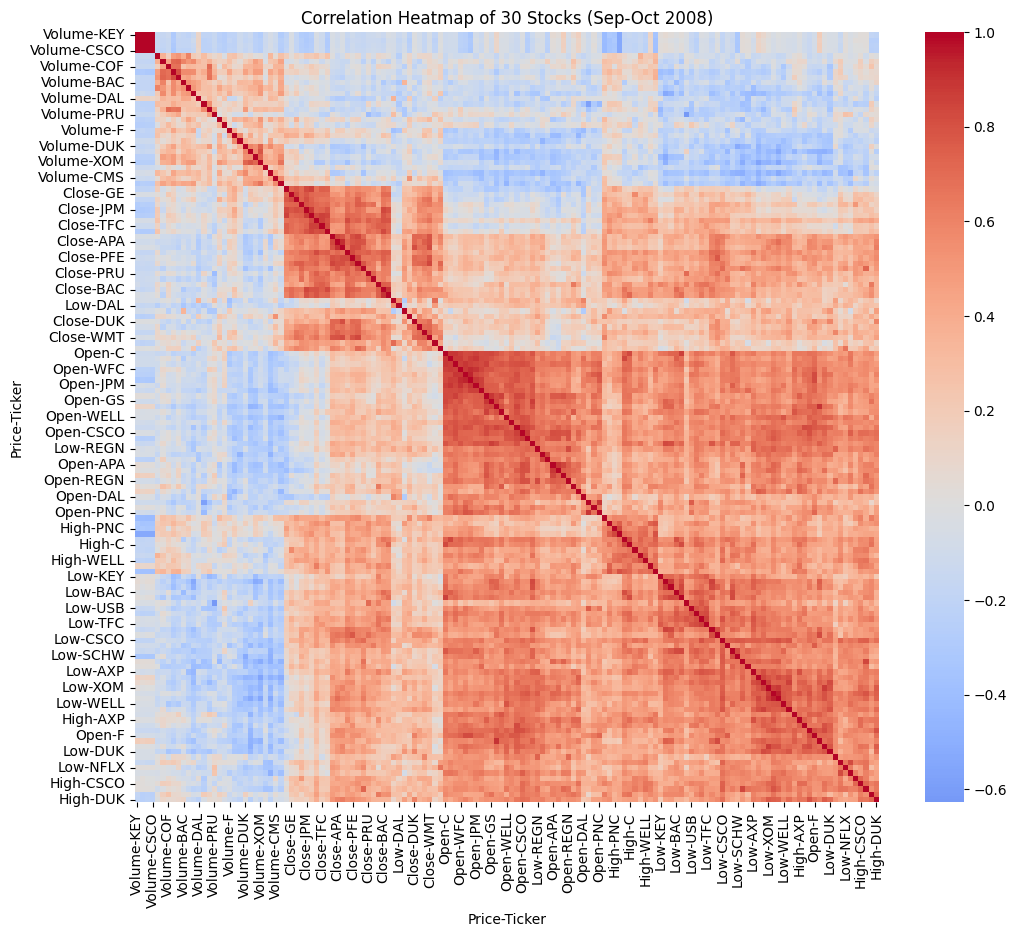

In [4]:
# Correlation matrix
corr_matrix = returns.corr()

# Hierarchical clustering to order the stocks
link = linkage(corr_matrix, method='ward')
dendro_order = leaves_list(link)
sorted_corr = corr_matrix.iloc[dendro_order, dendro_order]

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(sorted_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of 30 Stocks (Sep-Oct 2008)')
plt.show()

## **Step 6 : Define UCB Algorithm**

b)

In [5]:
def ucb_algorithm(rewards, n_rounds, c=2):
    n_arms = rewards.shape[0]
    counts = np.zeros(n_arms)
    sums_rewards = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)
    chosen_arms = []

    for t in range(n_rounds):
        if t < n_arms:
            arm = t # Play each arm once in the first n_arms rounds
        else:
            ucb_values = avg_rewards + c * np.sqrt(np.log(t + 1) / (counts + 1e-5))
            arm = np.argmax(ucb_values)

        reward = rewards[arm, t]
        counts[arm] += 1
        sums_rewards[arm] += reward
        avg_rewards[arm] = sums_rewards[arm] / counts[arm]
        chosen_arms.append(arm)

    return chosen_arms, avg_rewards

c)

Error: 'all_30_stocks_daily_returns_2008.csv' not found.
Please ensure the CSV file from Step 3c is in the correct directory.
Creating dummy data for demonstration purposes...
Dummy DataFrame created.
             STOCK_1   STOCK_2   STOCK_3   STOCK_4   STOCK_5   STOCK_6  \
2008-09-01  0.014235 -0.007203 -0.012877 -0.001864  0.009734  0.002177   
2008-09-02 -0.000457 -0.017028 -0.000354  0.000048 -0.015466 -0.015211   
2008-09-03  0.007662 -0.017572 -0.005333  0.006454  0.011477  0.012743   
2008-09-04  0.000886 -0.003272 -0.011697 -0.001962  0.000562  0.008922   
2008-09-05  0.005973  0.011107  0.013169  0.000184  0.007938  0.002198   

             STOCK_7   STOCK_8   STOCK_9  STOCK_10  ...  STOCK_21  STOCK_22  \
2008-09-01  0.011806  0.004368  0.000440  0.003075  ... -0.002781  0.001439   
2008-09-02 -0.005199 -0.000731 -0.007519  0.006832  ... -0.004132  0.005609   
2008-09-03 -0.012495 -0.005543 -0.000935  0.000868  ... -0.004565  0.013376   
2008-09-04 -0.014670  0.015315  0.0074

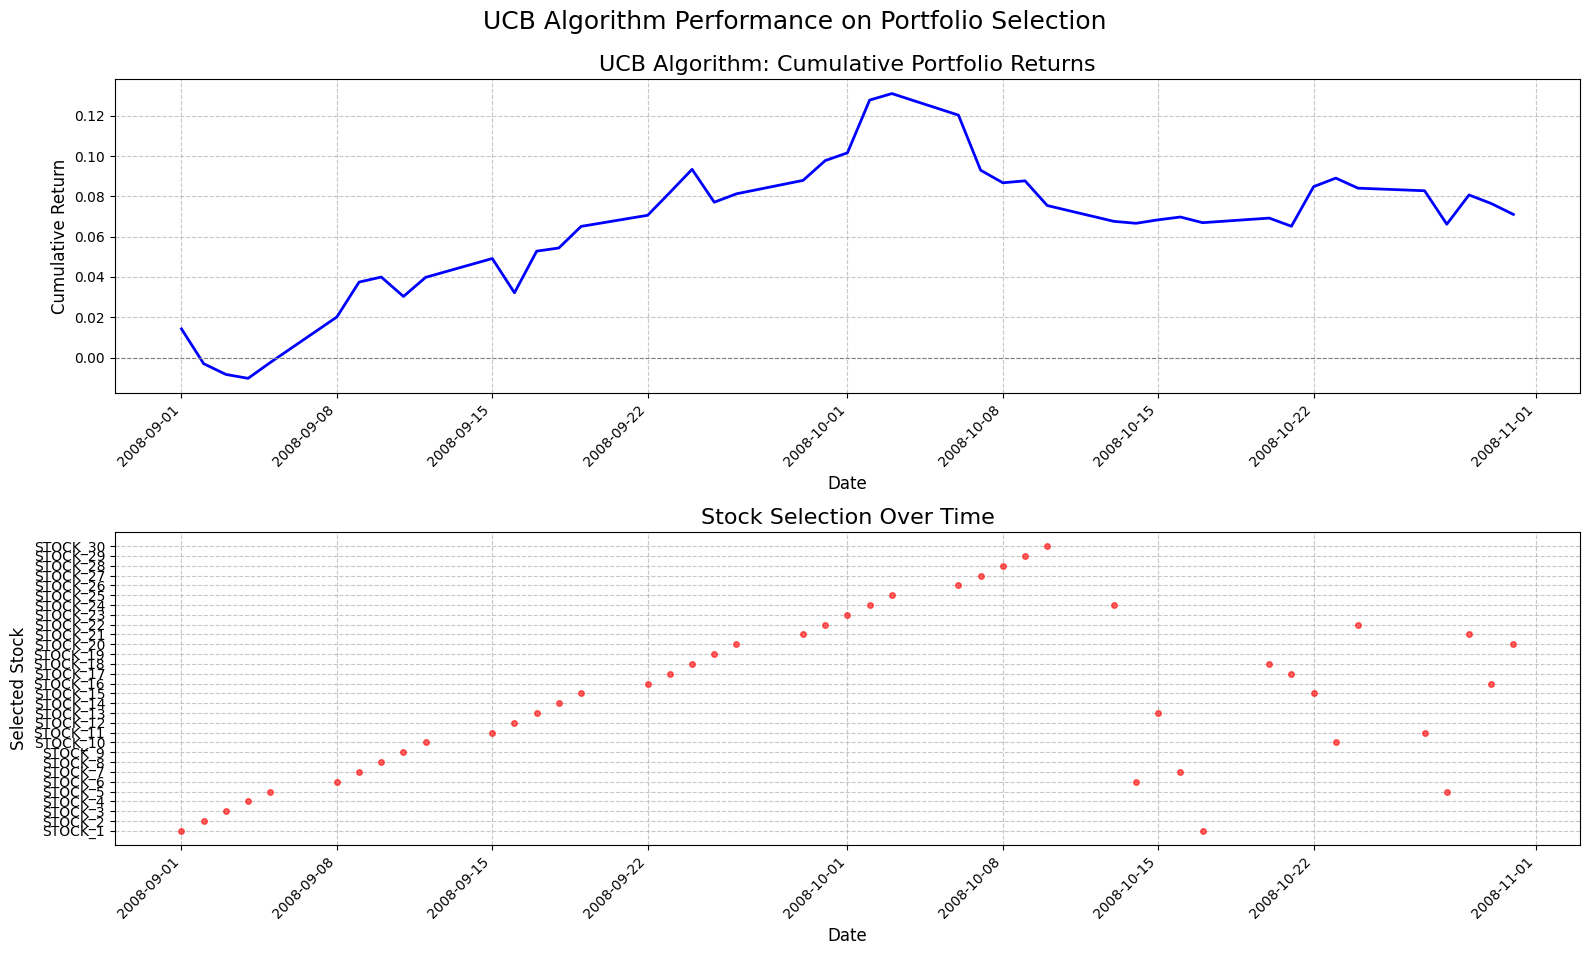


UCB Algorithm Results Summary
Total trading days simulated: 45
Final cumulative return: 0.0710 (7.10%)
Most frequently selected stock: STOCK_1 (Selected 2 times)
Least frequently selected stock: STOCK_2 (Selected 1 times)

Average returns by stock (based on UCB's internal estimates):
STOCK_1: 0.005805
STOCK_2: -0.017028
STOCK_3: -0.005333
STOCK_4: -0.001962
STOCK_5: -0.003702
STOCK_6: 0.010878
STOCK_7: 0.009134
STOCK_8: 0.002397
STOCK_9: -0.009256
STOCK_10: 0.006564
STOCK_11: 0.003897
STOCK_12: -0.016199
STOCK_13: 0.010820
STOCK_14: 0.001501
STOCK_15: 0.014299
STOCK_16: 0.000632
STOCK_17: 0.003388
STOCK_18: 0.006374
STOCK_19: -0.014912
STOCK_20: -0.000588
STOCK_21: 0.009888
STOCK_22: 0.002224
STOCK_23: 0.003507
STOCK_24: 0.008231
STOCK_25: 0.002860
STOCK_26: -0.009462
STOCK_27: -0.024394
STOCK_28: -0.005709
STOCK_29: 0.000878
STOCK_30: -0.011255

Results saved to 'ucb_algorithm_results.csv'


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UCB Algorithm Function
def ucb_algorithm(rewards, n_rounds, c=2):

    n_arms = rewards.shape[0]
    counts = np.zeros(n_arms)
    sums_rewards = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)
    chosen_arms = []

    for t in range(n_rounds):
        if t < n_arms:
            arm = t
        else:
            ucb_values = avg_rewards + c * np.sqrt(np.log(t + 1) / (counts + 1e-5))
            arm = np.argmax(ucb_values)

        if t < rewards.shape[1]:
            reward = rewards[arm, t]
        else:
            print(f"Warning: Ran out of reward data at round {t}. Stopping.")
            break

        # Update statistics for the chosen arm
        counts[arm] += 1
        sums_rewards[arm] += reward
        avg_rewards[arm] = sums_rewards[arm] / counts[arm]
        chosen_arms.append(arm)

    return chosen_arms, avg_rewards

# Data Loading and Preparation
try:
    daily_returns_df = pd.read_csv('all_30_stocks_daily_returns_2008.csv', index_col=0, parse_dates=True)
    print("Successfully loaded 'all_30_stocks_daily_returns_2008.csv'")
    print("DataFrame head:")
    print(daily_returns_df.head())
    print(f"DataFrame shape: {daily_returns_df.shape}")
    print("\nMissing values per column (should be 0 if previous step was clean):")
    print(daily_returns_df.isnull().sum())

    # Ensure no NaN values remain, as they will break the UCB algorithm
    if daily_returns_df.isnull().any().any():
        print("Warning: NaN values found in daily_returns_df. Dropping rows with NaNs.")
        daily_returns_df = daily_returns_df.dropna()
        if daily_returns_df.empty:
            raise ValueError("DataFrame became empty after dropping NaNs. Cannot proceed.")

except FileNotFoundError:
    print("Error: 'all_30_stocks_daily_returns_2008.csv' not found.")
    print("Please ensure the CSV file from Step 3c is in the correct directory.")
    # Create dummy data for demonstration if file not found
    print("Creating dummy data for demonstration purposes...")
    dates = pd.date_range(start='2008-09-01', end='2008-10-31', freq='B')
    num_stocks = 30
    stock_names = [f'STOCK_{i+1}' for i in range(num_stocks)]
    dummy_returns = np.random.randn(len(dates), num_stocks) * 0.01 # Simulate daily returns around 0
    daily_returns_df = pd.DataFrame(dummy_returns, index=dates, columns=stock_names)
    print("Dummy DataFrame created.")
    print(daily_returns_df.head())

rewards_matrix = daily_returns_df.T.values

# Get stock names (arms) from the DataFrame columns
stock_names = daily_returns_df.columns.tolist()

# Run the UCB algorithm
n_rounds = rewards_matrix.shape[1]  # Number of trading days (columns in transposed matrix)
print(f"\nRunning UCB algorithm for {n_rounds} rounds with {len(stock_names)} arms...")
chosen_arms, avg_rewards = ucb_algorithm(rewards_matrix, n_rounds, c=2)

# Convert arm indices to stock names for interpretability
chosen_stocks = [stock_names[arm] for arm in chosen_arms]

# Calculate cumulative portfolio returns
portfolio_returns = np.zeros(n_rounds)
for t, arm_idx in enumerate(chosen_arms):

    if t < rewards_matrix.shape[1]:
        portfolio_returns[t] = rewards_matrix[arm_idx, t]
    else:
        print(f"Warning: Index 't' ({t}) out of bounds for rewards_matrix columns ({rewards_matrix.shape[1]}).")
        break

cumulative_returns = np.cumprod(1 + portfolio_returns) - 1

# Plot results
plt.figure(figsize=(16, 10))

# Plot cumulative returns
plt.subplot(2, 1, 1)
# Ensure the index for plotting matches the length of cumulative_returns
plot_index = daily_returns_df.index[:len(cumulative_returns)]
plt.plot(plot_index, cumulative_returns, 'b-', linewidth=2)
plt.title('UCB Algorithm: Cumulative Portfolio Returns', fontsize=16)
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12) # Added xlabel for clarity
plt.xticks(rotation=45, ha='right') # Rotate and align for better date readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 return

# Plot stock selection over time
plt.subplot(2, 1, 2)
# Ensure the index for plotting matches the length of chosen_arms
plot_index_selection = daily_returns_df.index[:len(chosen_arms)]
plt.plot(plot_index_selection, chosen_arms, 'ro', markersize=4, alpha=0.6)
# Set y-ticks to show stock names
plt.yticks(range(len(stock_names)), stock_names, fontsize=10)
plt.title('Stock Selection Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Selected Stock', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.suptitle('UCB Algorithm Performance on Portfolio Selection', fontsize=18, y=0.98) # Overall title
plt.savefig('ucb_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nUCB Algorithm Results Summary")
print("=" * 50)
print(f"Total trading days simulated: {len(chosen_arms)}") # Use len(chosen_arms) as actual rounds completed
print(f"Final cumulative return: {cumulative_returns[-1]:.4f} ({cumulative_returns[-1]*100:.2f}%)")

# Calculate frequency of each stock selection
if chosen_arms: # Ensure chosen_arms is not empty
    stock_selection_counts = np.bincount(chosen_arms, minlength=len(stock_names))
    most_frequent_arm_idx = np.argmax(stock_selection_counts)
    least_frequent_arm_idx = np.argmin(stock_selection_counts) # This might be 0 if some arms were never chosen

    print(f"Most frequently selected stock: {stock_names[most_frequent_arm_idx]} (Selected {stock_selection_counts[most_frequent_arm_idx]} times)")
    print(f"Least frequently selected stock: {stock_names[least_frequent_arm_idx]} (Selected {stock_selection_counts[least_frequent_arm_idx]} times)")
else:
    print("No arms were chosen during the simulation.")

print("\nAverage returns by stock (based on UCB's internal estimates):")
for i, stock in enumerate(stock_names):
    # Only print if the arm was chosen at least once
    if avg_rewards[i] != 0 or np.sum(stock_selection_counts[i]) > 0:
        print(f"{stock}: {avg_rewards[i]:.6f}")
    else:
        print(f"{stock}: Not chosen (or average is 0)")


# Save results to CSV
# Ensure all arrays have the same length before creating DataFrame
min_len = min(len(plot_index), len(chosen_arms), len(chosen_stocks), len(portfolio_returns), len(cumulative_returns))

results_df = pd.DataFrame({
    'Date': plot_index[:min_len],
    'Chosen_Arm_Index': chosen_arms[:min_len], # Renamed for clarity
    'Chosen_Stock': chosen_stocks[:min_len],
    'Daily_Portfolio_Return': portfolio_returns[:min_len], # Renamed for clarity
    'Cumulative_Portfolio_Return': cumulative_returns[:min_len] # Renamed for clarity
})
results_df.to_csv('ucb_algorithm_results.csv', index=False)
print("\nResults saved to 'ucb_algorithm_results.csv'")

## Steps 8 : Define Epsilon-Greedy Algorithm

In [7]:
def epsilon_greedy_algorithm(rewards, n_rounds, epsilon=0.1):
    n_arms = rewards.shape[0]
    counts = np.zeros(n_arms)
    sums_rewards = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)
    chosen_arms = []

    for t in range(n_rounds):
        if np.random.rand() < epsilon:
            arm = np.random.randint(n_arms)
        else:
            arm = np.argmax(avg_rewards)

        reward = rewards[arm, t]
        counts[arm] += 1
        sums_rewards[arm] += reward
        avg_rewards[arm] = sums_rewards[arm] / counts[arm]
        chosen_arms.append(arm)

    return chosen_arms, avg_rewards

In [8]:
# Convert returns dataframe to numpy array (shape: n_arms x n_rounds)
reward_matrix = returns.T.values  # transpose to get arms in rows, rounds in columns

n_arms, n_rounds = reward_matrix.shape

print(f'Number of arms (stocks): {n_arms}')
print(f'Number of rounds (days): {n_rounds}')

Number of arms (stocks): 145
Number of rounds (days): 42


In [9]:
chosen_arms_ucb, avg_rewards_ucb = ucb_algorithm(reward_matrix, n_rounds, c=2)

print('Average rewards from UCB for each arm:')
for i, avg_r in enumerate(avg_rewards_ucb):
    print(f'{returns.columns[i]}: {avg_r:.6f}')

Average rewards from UCB for each arm:
('Close', 'AXP'): 0.006891
('Close', 'BAC'): -0.071602
('Close', 'C'): 0.042077
('Close', 'COF'): 0.089913
('Close', 'GS'): -0.047487
('Close', 'JPM'): -0.001774
('Close', 'KEY'): 0.019109
('Close', 'MS'): -0.038233
('Close', 'PNC'): -0.034946
('Close', 'PRU'): 0.091536
('Close', 'SCHW'): -0.105965
('Close', 'TFC'): 0.114560
('Close', 'USB'): 0.033180
('Close', 'WFC'): -0.116080
('High', 'AXP'): -0.049383
('High', 'BAC'): -0.024542
('High', 'C'): 0.008500
('High', 'COF'): 0.057489
('High', 'GS'): -0.024422
('High', 'JPM'): -0.002316
('High', 'KEY'): 0.182708
('High', 'MS'): 0.010052
('High', 'PNC'): 0.012659
('High', 'PRU'): -0.130029
('High', 'SCHW'): 0.081798
('High', 'TFC'): 0.019003
('High', 'USB'): -0.038794
('High', 'WFC'): -0.107046
('Low', 'AXP'): 0.155610
('Low', 'BAC'): 0.154734
('Low', 'C'): -0.078341
('Low', 'COF'): -0.061995
('Low', 'GS'): 0.028846
('Low', 'JPM'): -0.006656
('Low', 'KEY'): 0.045455
('Low', 'MS'): -0.062564
('Low', 'PN

In [10]:
chosen_arms_eps, avg_rewards_eps = epsilon_greedy_algorithm(reward_matrix, n_rounds, epsilon=0.1)

print('Average rewards from Epsilon-Greedy for each arm:')
for i, avg_r in enumerate(avg_rewards_eps):
    print(f'{returns.columns[i]}: {avg_r:.6f}')


Average rewards from Epsilon-Greedy for each arm:
('Close', 'AXP'): -0.022954
('Close', 'BAC'): -0.003623
('Close', 'C'): 0.010095
('Close', 'COF'): 0.000000
('Close', 'GS'): 0.000000
('Close', 'JPM'): 0.000000
('Close', 'KEY'): 0.000000
('Close', 'MS'): 0.000000
('Close', 'PNC'): 0.000000
('Close', 'PRU'): 0.000000
('Close', 'SCHW'): 0.000000
('Close', 'TFC'): 0.000000
('Close', 'USB'): 0.000000
('Close', 'WFC'): 0.000000
('High', 'AXP'): 0.000000
('High', 'BAC'): 0.000000
('High', 'C'): 0.000000
('High', 'COF'): 0.000000
('High', 'GS'): 0.000000
('High', 'JPM'): 0.000000
('High', 'KEY'): 0.000000
('High', 'MS'): 0.000000
('High', 'PNC'): 0.000000
('High', 'PRU'): 0.000000
('High', 'SCHW'): 0.000000
('High', 'TFC'): 0.000000
('High', 'USB'): 0.000000
('High', 'WFC'): 0.000000
('Low', 'AXP'): 0.000000
('Low', 'BAC'): 0.000000
('Low', 'C'): 0.000000
('Low', 'COF'): 0.000000
('Low', 'GS'): 0.000000
('Low', 'JPM'): 0.000000
('Low', 'KEY'): 0.000000
('Low', 'MS'): 0.000000
('Low', 'PNC'): 

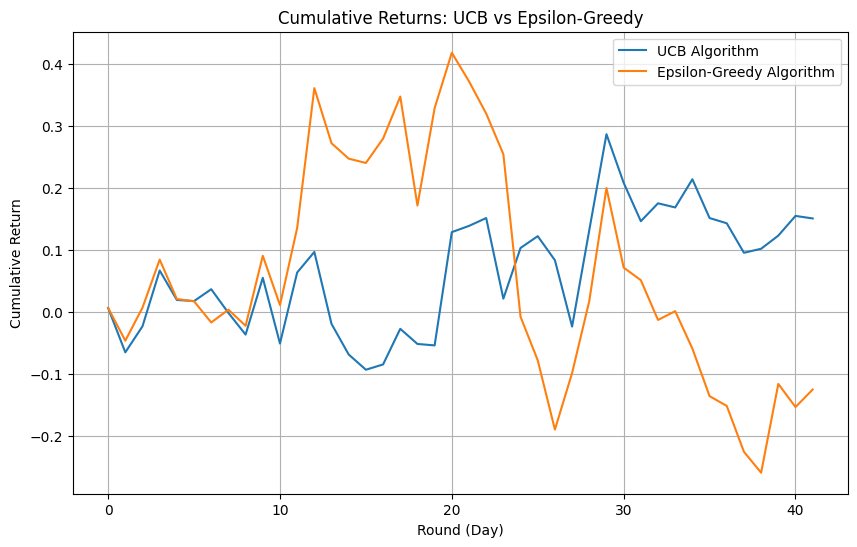

In [11]:
def cumulative_rewards(chosen_arms, rewards):
    total_reward = 0
    rewards_list = []
    for t, arm in enumerate(chosen_arms):
        # Ensure we don't go out of bounds for rewards matrix
        if t < rewards.shape[1]:
            reward = rewards[arm, t]
            total_reward += reward
            rewards_list.append(total_reward)
        else:
            # If chosen_arms is longer than rewards columns, stop accumulating
            break
    return rewards_list

cum_rewards_ucb = cumulative_rewards(chosen_arms_ucb, reward_matrix)
cum_rewards_eps = cumulative_rewards(chosen_arms_eps, reward_matrix)

plt.figure(figsize=(10,6))
plt.plot(cum_rewards_ucb, label='UCB Algorithm')
plt.plot(cum_rewards_eps, label='Epsilon-Greedy Algorithm')
plt.xlabel('Round (Day)')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Returns: UCB vs Epsilon-Greedy')
plt.legend()
plt.grid(True)
plt.show()

## Step 10

[*********************100%***********************]  14 of 14 completed
[*********************100%***********************]  15 of 15 completed


Sample daily returns:
Number of arms (stocks): 145
Number of rounds (days): 41
Average rewards from UCB for each arm:
('Close', 'AXP'): -0.051462
('Close', 'BAC'): 0.023063
('Close', 'C'): -0.057872
('Close', 'COF'): -0.032792
('Close', 'GS'): -0.103915
('Close', 'JPM'): 0.077697
('Close', 'KEY'): -0.083770
('Close', 'MS'): -0.150800
('Close', 'PNC'): 0.129434
('Close', 'PRU'): -0.180839
('Close', 'SCHW'): 0.102094
('Close', 'TFC'): -0.032456
('Close', 'USB'): 0.006364
('Close', 'WFC'): -0.063273
('High', 'AXP'): -0.085153
('High', 'BAC'): 0.075242
('High', 'C'): 0.092375
('High', 'COF'): 0.116364
('High', 'GS'): -0.023440
('High', 'JPM'): -0.007908
('High', 'KEY'): -0.033808
('High', 'MS'): -0.081610
('High', 'PNC'): 0.013332
('High', 'PRU'): -0.031486
('High', 'SCHW'): 0.041464
('High', 'TFC'): 0.063837
('High', 'USB'): -0.026836
('High', 'WFC'): 0.112533
('Low', 'AXP'): -0.059063
('Low', 'BAC'): -0.028596
('Low', 'C'): -0.021135
('Low', 'COF'): -0.007233
('Low', 'GS'): 0.034225
('Lo

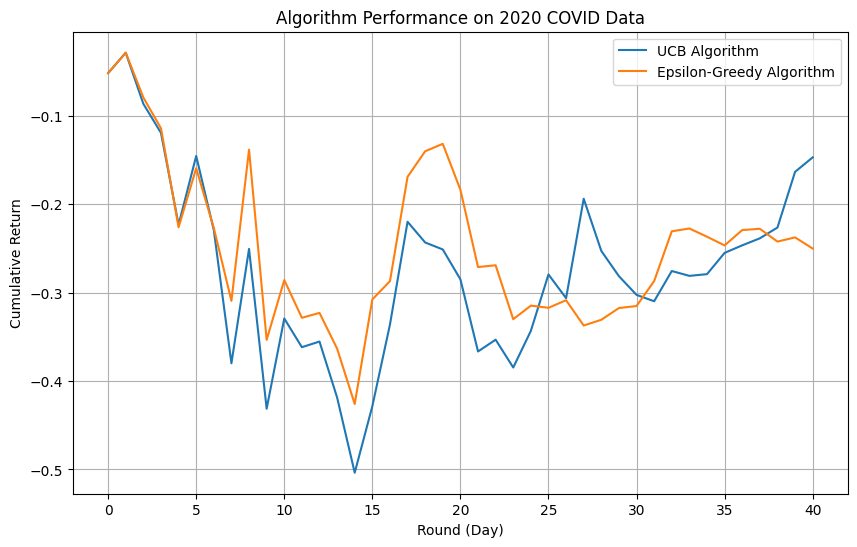

In [12]:
# Download recent data (COVID period)
recent_start = '2020-03-01'
recent_end = '2020-04-30'

recent_fin = yf.download(fin_symbols, start=recent_start, end=recent_end, auto_adjust=True)
recent_nonfin = yf.download(nonfin_symbols, start=recent_start, end=recent_end, auto_adjust=True)
recent_returns = pd.concat([recent_fin, recent_nonfin], axis=1).pct_change().dropna()

print('Sample daily returns:')
recent_returns.head()

# Convert returns dataframe to numpy array (shape: n_arms x n_rounds)
reward_matrix_recent = recent_returns.T.values  # transpose to get arms in rows, rounds in columns

n_arms_recent, n_rounds_recent = reward_matrix_recent.shape

print(f'Number of arms (stocks): {n_arms_recent}')
print(f'Number of rounds (days): {n_rounds_recent}')

chosen_arms_ucb_recent, avg_rewards_ucb_recent = ucb_algorithm(rewards=reward_matrix_recent, n_rounds=n_rounds_recent, c=2)

print('Average rewards from UCB for each arm:')
for i, avg_r in enumerate(avg_rewards_ucb_recent):
    print(f'{recent_returns.columns[i]}: {avg_r:.6f}')

chosen_arms_eps_recent, avg_rewards_eps_recent = epsilon_greedy_algorithm(rewards=reward_matrix_recent, n_rounds=n_rounds_recent, epsilon=0.1)

print('Average rewards from Epsilon-Greedy for each arm:')
for i, avg_r in enumerate(avg_rewards_eps_recent):
    print(f'{recent_returns.columns[i]}: {avg_r:.6f}')

cum_rewards_ucb_recent = cumulative_rewards(chosen_arms=chosen_arms_ucb_recent, rewards=reward_matrix_recent)
cum_rewards_eps_recent = cumulative_rewards(chosen_arms=chosen_arms_eps_recent, rewards=reward_matrix_recent)

plt.figure(figsize=(10,6))
plt.plot(cum_rewards_ucb_recent, label='UCB Algorithm')
plt.plot(cum_rewards_eps_recent, label='Epsilon-Greedy Algorithm')
plt.xlabel('Round (Day)')
plt.ylabel('Cumulative Return')
plt.title('Algorithm Performance on 2020 COVID Data')
plt.legend()
plt.grid(True)
plt.show()

## Step 11

[*********************100%***********************]  14 of 14 completed
[*********************100%***********************]  15 of 15 completed


Sample daily returns:
Ticker           AXP       BAC         C       COF        GS       JPM  \
Date                                                                     
2020-03-03 -0.051462 -0.055158 -0.037579 -0.055209 -0.028835 -0.037525   
2020-03-04  0.071197  0.023063  0.035972  0.033673  0.026102  0.024709   
2020-03-05 -0.041141 -0.050691 -0.057872 -0.047577 -0.047667 -0.049061   
2020-03-06 -0.024337 -0.039955 -0.034809 -0.032792 -0.029881 -0.051680   
2020-03-09 -0.091926 -0.147024 -0.161717 -0.112043 -0.103915 -0.135455   

Ticker           KEY        MS       PNC       PRU  ...      EQIX         F  \
Date                                                ...                       
2020-03-03 -0.044785 -0.044751 -0.053905 -0.056561  ... -0.006011 -0.031944   
2020-03-04  0.029611  0.018919  0.031158  0.028111  ...  0.049305  0.015782   
2020-03-05 -0.042540 -0.058576 -0.067311 -0.063625  ... -0.044648 -0.048023   
2020-03-06 -0.069462 -0.017610 -0.053526 -0.033905  ... -0.01297

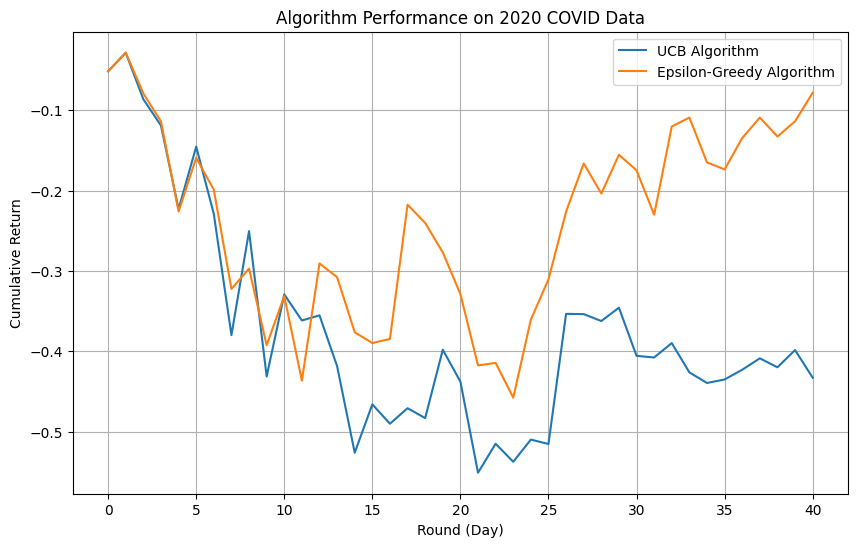

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define ticker symbols (same as before)
fin_symbols = ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC']
nonfin_symbols = ['KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS', 'WELL']

# Download recent data (COVID period)
recent_start = '2020-03-01'
recent_end = '2020-04-30'

recent_fin = yf.download(fin_symbols, start=recent_start, end=recent_end, auto_adjust=True)
recent_nonfin = yf.download(nonfin_symbols, start=recent_start, end=recent_end, auto_adjust=True)

# Compute daily returns and combine
recent_returns = pd.concat([recent_fin['Close'], recent_nonfin['Close']], axis=1).pct_change().dropna()
print('Sample daily returns:')
print(recent_returns.head())

# Convert returns dataframe to numpy array (shape: arms x rounds)
reward_matrix_recent = recent_returns.T.values  # transpose to get arms in rows, rounds in columns
n_arms_recent, n_rounds_recent = reward_matrix_recent.shape
print(f'Number of arms (stocks): {n_arms_recent}')
print(f'Number of rounds (days): {n_rounds_recent}')

# Define the UCB Algorithm function (using the corrected version from earlier)
def ucb_algorithm(rewards, n_rounds, c=2):
    n_arms = rewards.shape[0]
    counts = np.zeros(n_arms)
    sums_rewards = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)
    chosen_arms = []

    for t in range(n_rounds):
        if t < n_arms:
            arm = t  # Play each arm once in the first n_arms rounds
        else:
            ucb_values = avg_rewards + c * np.sqrt(np.log(t + 1) / (counts + 1e-5))
            arm = np.argmax(ucb_values)

        reward = rewards[arm, t]
        counts[arm] += 1
        sums_rewards[arm] += reward
        avg_rewards[arm] = sums_rewards[arm] / counts[arm]
        chosen_arms.append(arm)

    return chosen_arms, avg_rewards

# Define the Epsilon-Greedy Algorithm function (using the corrected version from earlier)
def epsilon_greedy_algorithm(rewards, n_rounds, epsilon=0.1):
    n_arms = rewards.shape[0]
    counts = np.zeros(n_arms)
    sums_rewards = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)
    chosen_arms = []

    for t in range(n_rounds):
        if np.random.rand() < epsilon:
            arm = np.random.randint(n_arms)
        else:
            # Handle the case where all avg_rewards are 0 initially
            if np.all(avg_rewards == 0) and t > 0:
                 arm = np.random.randint(n_arms) # Explore randomly if no info yet
            else:
                arm = np.argmax(avg_rewards)

        reward = rewards[arm, t]
        counts[arm] += 1
        sums_rewards[arm] += reward
        # Avoid division by zero
        avg_rewards[arm] = sums_rewards[arm] / counts[arm] if counts[arm] > 0 else 0
        chosen_arms.append(arm)

    return chosen_arms, avg_rewards


# Define the cumulative_rewards function (using the corrected version from earlier)
def cumulative_rewards(chosen_arms, rewards):
    cum_rewards = []
    total = 0
    for t, arm in enumerate(chosen_arms):
        # Ensure we don't go out of bounds for rewards matrix
        if t < rewards.shape[1]:
            total += rewards[arm, t]
            cum_rewards.append(total)
        else:
            # If chosen_arms is longer than rewards columns, stop accumulating
            break
    return cum_rewards


# Run UCB and epsilon-Greedy on recent data
chosen_arms_ucb_recent, avg_rewards_ucb_recent = ucb_algorithm(rewards=reward_matrix_recent, n_rounds=n_rounds_recent, c=2)
print('Average rewards from UCB for each arm:')
for i, avg_r in enumerate(avg_rewards_ucb_recent):
     # Ensure the index is within the bounds of recent_returns.columns
    if i < len(recent_returns.columns):
        print(f'{recent_returns.columns[i]}: {avg_r:.6f}')
    else:
        print(f'Arm {i}: {avg_r:.6f}')


chosen_arms_eps_recent, avg_rewards_eps_recent = epsilon_greedy_algorithm(rewards=reward_matrix_recent, n_rounds=n_rounds_recent, epsilon=0.1)
print('Average rewards from Epsilon-Greedy for each arm:')
for i, avg_r in enumerate(avg_rewards_eps_recent):
     # Ensure the index is within the bounds of recent_returns.columns
    if i < len(recent_returns.columns):
        print(f'{recent_returns.columns[i]}: {avg_r:.6f}')
    else:
        print(f'Arm {i}: {avg_r:.6f}')


# Calculate cumulative rewards for plotting
cum_rewards_ucb_recent = cumulative_rewards(chosen_arms=chosen_arms_ucb_recent, rewards=reward_matrix_recent)
cum_rewards_eps_recent = cumulative_rewards(chosen_arms=chosen_arms_eps_recent, rewards=reward_matrix_recent)


# Plot algorithm performance
plt.figure(figsize=(10, 6))
plt.plot(cum_rewards_ucb_recent, label='UCB Algorithm')
plt.plot(cum_rewards_eps_recent, label='Epsilon-Greedy Algorithm')
plt.xlabel('Round (Day)')
plt.ylabel('Cumulative Return')
plt.title('Algorithm Performance on 2020 COVID Data')
plt.legend()
plt.grid(True)
plt.show()